# Basic usage

This tutorial demonstrates the basic usage of the `raves` Python package.

In [1]:
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as pathefx

from IPython.display import Audio, display

from numpy.random import default_rng
from scipy.signal import butter, sosfilt
from scipy.interpolate import make_interp_spline

from raves import raves, run_ART, run_MoDART
from raves.src.compute_MoDART import plot_T60
from raves.src.utils.raves_io import visualize_mesh

## Step 1: Choose an environment

To begin with, let us choose the environment to be analyzed: one of the examples provided with this repository.
The `DampenedMiddle` environment consists of three rectangular rooms of comparable size, where the middle room is the least reverberant.
Several variants are provided, with differing levels of surface discretization; `DampenedMiddle_20_patches` is the coarsest one, with the fewest surface patches.

The pre-processing step expects to find three files in the environment folder: `materials.csv`, `mesh.mtl`, and `mesh.obj`.
The format specifications of these input files are detailed in `README.md`.

In [2]:
environment_folder = os.path.join('..', 'example environments', 'DampenedMiddle_20_patches')

The following line allows us to visualize the 3D mesh of the environment.
The visualization opens in a separate window.
This function requires some optional dependencies, and will only work if `raves` has been installed with the command
```
pip install raves[mesh_vis]
```

In [3]:
visualize_mesh(environment_folder)

## Step 2: Pre-processing

Having selected the folder we want to analyze, let's run the pre-processing step.
Note that the ART surface integration will be skipped if ART kernels are already present in the folder (as is the case for the provided example).
If you want to run the integration anyway, overwriting any existing data, you can use the `overwrite` argument.

After either loading or computing the ART kernels and related data, the MoD-ART analysis will be run.
In the console output of this function, we see that each frequency band is analyzed in turn.
In each band, the process first constructs the state transition matrix of the ART model, and then locates its (real, positive) eigenvalues of largest magnitude.
The search is conducted economically, iteratively using larger numbers of estimates until a reverberation time below the stopping threshold is found.

In [4]:

raves(environment_folder)

Running `compute_ART` in the environment "DampenedMiddle_20_patches"
8 cores available. Pool will use 4 SUB-processes.

Core ART files already exist. They will be read and re-used.
Current material data will be read and used to make new frequency-band kernels.
If you want to overwrite the existing core files, pass the argument `--overwrite` to the script.


Running `compute_MoDART` in the environment "DampenedMiddle_20_patches"

Analyzing frequency band #1.
	Generating full state transition matrix.
	Eigenvalue search (right eigenvectors).
		Searching with 4 estimates.
			Lowest found T60 is 210% of stopping value.
		Searching with 8 estimates.
			Lowest found T60 is 134% of stopping value.
		Searching with 16 estimates.
			Lowest found T60 is 111% of stopping value.
		Searching with 32 estimates.
			Lowest found T60 is 80% of stopping value.
	Eigenvalue search (left eigenvectors).
	Rearranging and scaling results.

Analyzing frequency band #2.
	Generating full state transition matrix.


Let's display the results of the analysis.  
This plot will show the $T_{60}$ of all energy modes (i.e., slopes of the acoustic energy decay) found in the analysis.
The analysis is performed separately for each frequency band, and energy modes are grouped accordingly in the plot.

Plotting results.


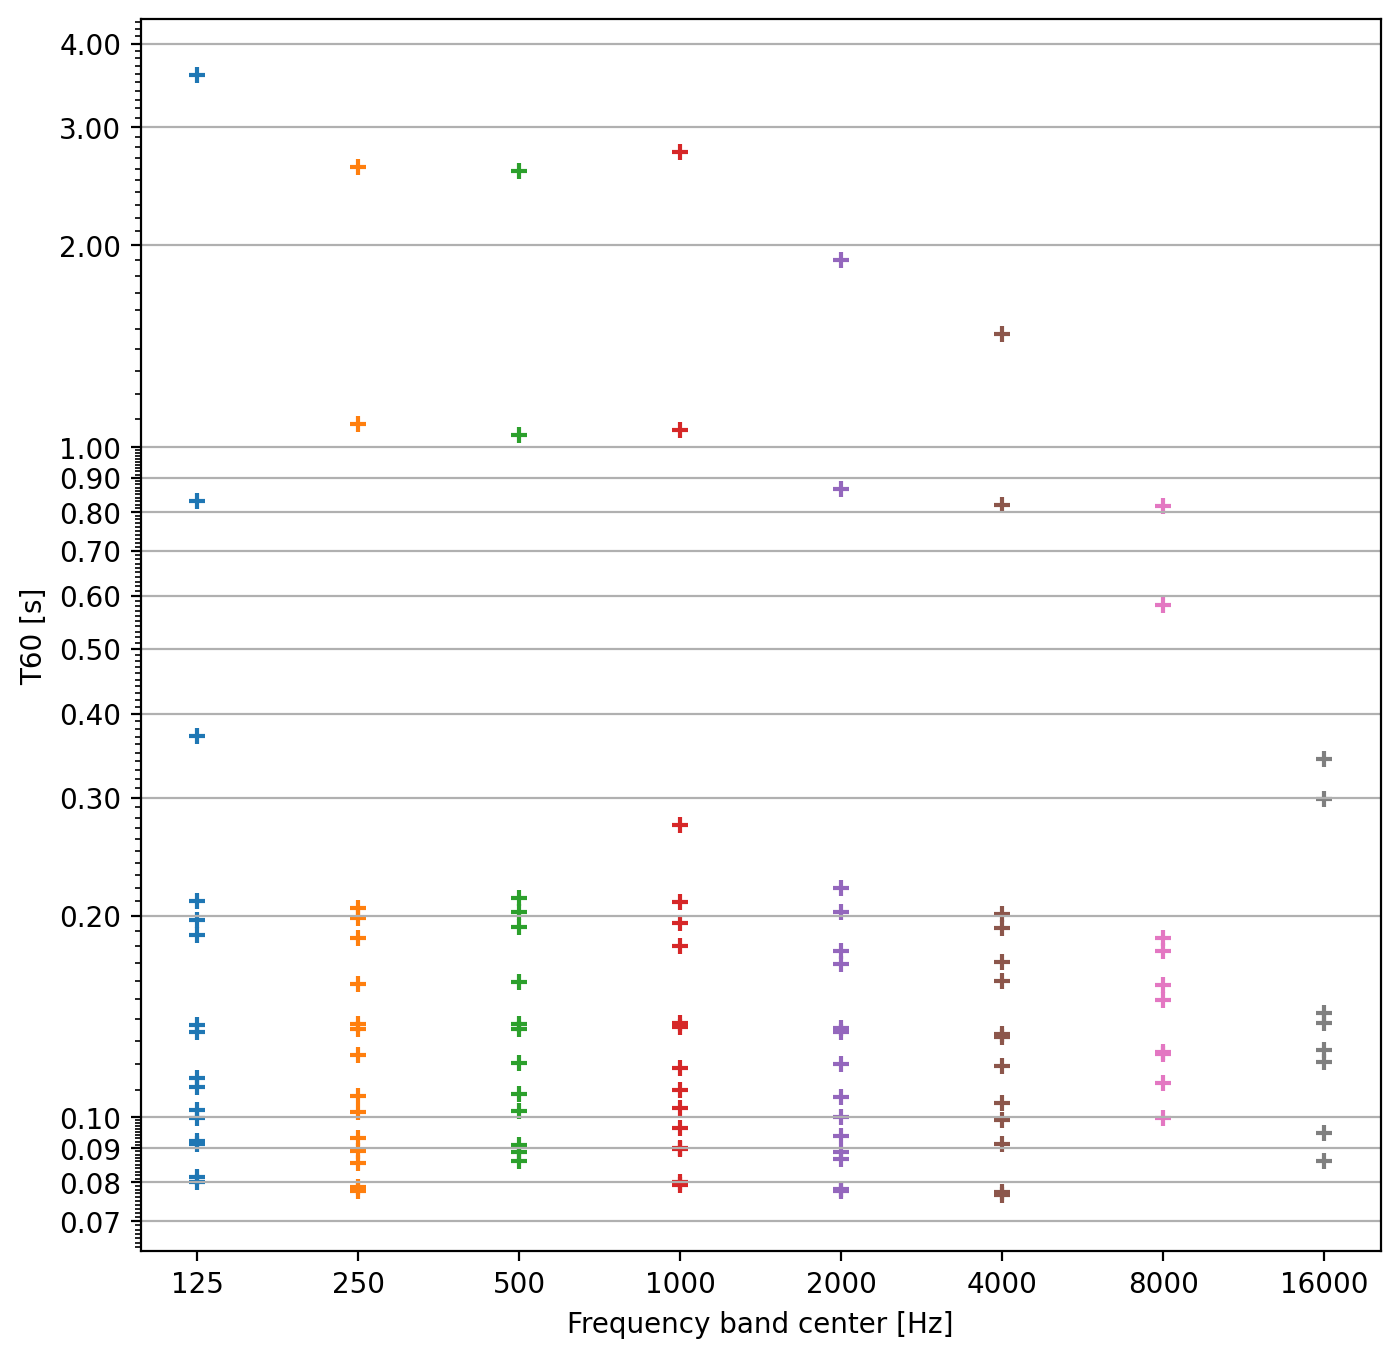

In [5]:
plot_T60(environment_folder, show_figure=True)

## Step 3: Echogram generation

You may have noticed that we did not specify the positions of sound sources and listeners within the environment.
The processing we have performed so far is an analysis of the environment as a whole, and the energy modes shown in the plot above are position-independent characteristics.

Now, let us define a few positions for sound sources and listeners, and evaluate point-to-point reverberation between them.

In [6]:
source_positions = np.array([[2.1, 1.9, 1.5],
                             [5.8, 4.1, 1.5],
                             [7.2, 6.5, 1.5]])
listener_positions = np.array([[3., 3.5, 1.75],
                               [9., 3.5, 1.75],
                               [9., 9.5, 1.75],])

We are going to express reverberation in the form of "echograms".
In other words, we will evaluate the envelopes of the point-to-point room impulse responses' energy, devoid of phase information.  
In order to capture the frequency-dependent effects of surface material properties and air absorption, we will generate separate echograms for each analyzed frequency band.
The echograms we are going to produce will thus be arrays of shape `(S, L, B, T)`, where:
* `S` is the number of sound source positions;
* `L` is the number of listener positions;
* `B` is the number of frequency bands;
* `T` is the duration of the echograms, in samples.

Let's start by specifying the length of time over which we want to evaluate energy decay, and the sample rate to be used by the echograms.
> **_NOTE:_** The sample rate specified here is **not** an audio rate in the conventional sense. Its main effects in this context are reflected in the discretization of propagation times within the ART model, and in the temporal resolution of the resulting energy envelope.

In [7]:
# Duration of the impulse responses to be generated, in seconds.
response_duration = 1.5
# Sample rate used for the echograms. Mostly relevant to avoid rounding errors in the propagation delays.
echogram_sample_rate = 1e4

### Step 3a: TD-ART

We will first evaluate the echograms using regular (time-domain) acoustic radiance transfer, as a reference.  
We also record the runtime of this operation, to compare it with MoD-ART.

Internally, the `run_ART` function is going to:
1. load the ART pre-processing results from the specified folder;
2. trace rays from each sound source position, taking note of which propagation paths receive acoustic energy, how much, and after how much delay;
3. trace rays from each listener position, taking note of which propagation paths provide acoustic energy, how much, and after how much delay;
4. assemble echograms for each frequency band using the iterative TD-ART algorithm;
5. return the resulting echograms alongside the frequency band centers, used for plotting.

In [8]:
start_time = time.time()
ART_echograms, frequencies = run_ART(environment_folder, source_positions, listener_positions,
                                     echogram_sample_rate=echogram_sample_rate,
                                     echogram_duration=response_duration)
ART_runtime = time.time() - start_time

Running `run_ART` in the environment "DampenedMiddle_20_patches"
Processing source 1
	No output folder specified.
	Computing ray-tracing...
Processing source 2
	No output folder specified.
	Computing ray-tracing...
Processing source 3
	No output folder specified.
	Computing ray-tracing...
Processing listener 1
	No output folder specified.
	Computing ray-tracing...
Processing listener 2
	No output folder specified.
	Computing ray-tracing...
Processing listener 3
	No output folder specified.
	Computing ray-tracing...
All components ready. Assembling echograms.
	Frequency band 1...
	Frequency band 2...
	Frequency band 3...
	Frequency band 4...
	Frequency band 5...
	Frequency band 6...
	Frequency band 7...
	Frequency band 8...
Adding line-of-sight components where unobstructed.


### Step 3b: MoD-ART

Now, we will evaluate the echograms using the modal decomposition of acoustic radiance transfer.

Internally, the `run_MoDART` function is going to:
1. load the MoD-ART pre-processing results (including the modes we plotted) from the specified folder;
2. trace rays from each sound source position like before, but this time use the results to evaluate the energy mode residues;
3. trace rays from each listener position like before, but this time use the results to evaluate the energy mode residues;
4. assemble echograms for each frequency band as a simple sum of weighted exponential terms;
5. return the resulting echograms alongside the frequency band centers and full MoD-ART data, which we ignore for this exercise.

In [9]:
start_time = time.time()
MoDART_echograms, _, _ = run_MoDART(environment_folder, source_positions, listener_positions,
                                    echogram_sample_rate=echogram_sample_rate,
                                    echogram_duration=response_duration)
MoDART_runtime = time.time() - start_time

Running `run_MoDART` in the environment "DampenedMiddle_20_patches"
Processing source 1
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing source 2
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing source 3
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 1
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 2
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
Processing listener 3
	No output folder specified.
	Computing ray-tracing...
	Computing residues...
All residues ready. Assembling echograms.
Adding line-of-sight components where unobstructed.


Let's compare the runtime of the two approaches...

In [10]:
print('TD-ART took {:.3f} seconds to generate the echograms.'.format(ART_runtime))
print('MoD-ART took {:.3f} seconds to generate the echograms.'.format(MoDART_runtime))
print('MoD-ART took {:.2f}% as long as TD-ART.'.format(100. * MoDART_runtime / ART_runtime))

TD-ART took 38.933 seconds to generate the echograms.
MoD-ART took 0.726 seconds to generate the echograms.
MoD-ART took 1.86% as long as TD-ART.


## Step 4: Plot echogram results

Finally, let's visually compare the echograms produced by the two approaches.  
We will plot both the echograms themselves, and their energy decay curves (backwards integration).

We will only plot the echograms in one frequency band, for all combinations of sound source and listener positions.

In [11]:
displayed_band_idx = 5
displayed_duration = response_duration / 2

# Prepare a time axis for the plots.
echogram_time_axis = np.arange(0, response_duration, 1 / echogram_sample_rate)
num_bands = len(frequencies)
num_sources = len(source_positions)
num_listeners = len(listener_positions)
# Number of (echogram) samples actually shown displayed the plots:
displayed_len = min(len(echogram_time_axis), int(displayed_duration * echogram_sample_rate))

### Step 4a: Echograms

First, the echograms themselves.  
We will use the same y-axis extent in all subplots.

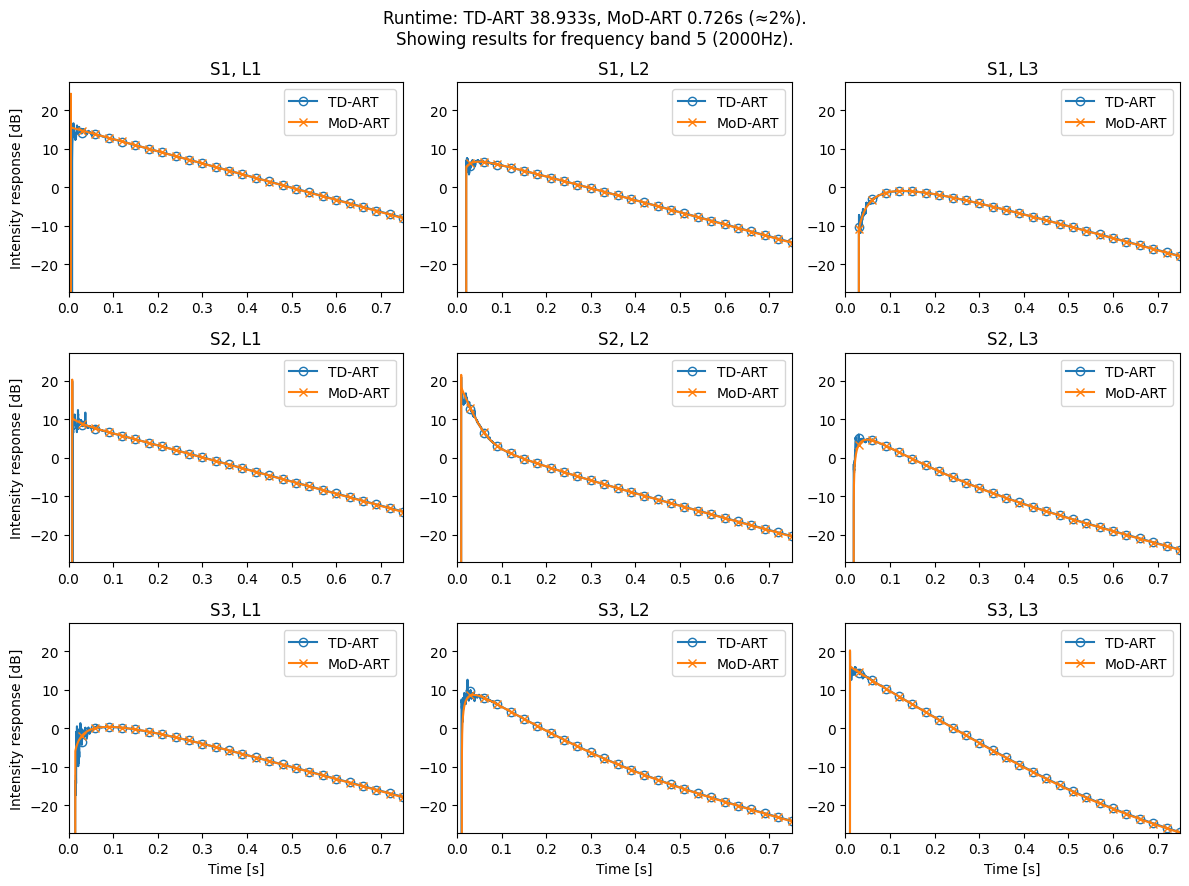

In [12]:
# Clip the echograms strictly above 0 and convert to dB.
ART_echograms_clipped = np.clip(ART_echograms, 1e-20, None)
MoDART_echograms_clipped = np.clip(MoDART_echograms, 1e-20, None)
ART_echograms_dB = 10 * np.log10(ART_echograms_clipped)
MoDART_echograms_dB = 10 * np.log10(MoDART_echograms_clipped)

# Consider the extent of the dB range to be plotted.
max_extent = max(np.max(ART_echograms_dB[:, :, displayed_band_idx-1, :displayed_len]),
                 np.max(MoDART_echograms_dB[:, :, displayed_band_idx-1, :displayed_len]))
min_extent = min(np.min(ART_echograms_dB[:, :, displayed_band_idx-1, displayed_len]),
                 np.min(MoDART_echograms_dB[:, :, displayed_band_idx-1, displayed_len]))

fig, ax = plt.subplots(num_sources, num_listeners,
                       figsize=(4*num_listeners, 3*num_sources))

for s in range(num_sources):
    for l in range(num_listeners):
        ax[s, l].plot(echogram_time_axis, ART_echograms_dB[s, l, displayed_band_idx-1],
                      label='TD-ART', marker='o', fillstyle='none',
                      markevery=int(3e-2 * echogram_sample_rate))
        ax[s, l].plot(echogram_time_axis, MoDART_echograms_dB[s, l, displayed_band_idx-1],
                      label='MoD-ART', marker='x',
                      markevery=int(3e-2 * echogram_sample_rate))
        
        ax[s, l].legend()
        ax[s, l].set_xlim(0, displayed_duration)
        ax[s, l].set_ylim(min_extent, max_extent + 3)
        
        ax[s, l].set_title('S{}, L{}'.format(s+1, l+1))
        if l == 0:
            ax[s, l].set_ylabel('Intensity response [dB]')
        if s == num_sources-1:
            ax[s, l].set_xlabel('Time [s]')

plt.suptitle('Runtime: TD-ART {:.3f}s, MoD-ART {:.3f}s (≈{:.0f}%).'.format(ART_runtime, MoDART_runtime, 100. * MoDART_runtime / ART_runtime)
             + '\nShowing results for frequency band {} ({:.0f}Hz).'.format(displayed_band_idx, frequencies[displayed_band_idx-1]))
plt.tight_layout()

plt.show()

### Step 4b: Energy decay curves

Now, we plot the backwards integration of the echograms.
Note that we do not normalize these by the total energy, in order to compare the relative overall loudness of different configurations.
The leftmost value (at time 0) of each plot is the total energy of that point-to-point room impulse response in the selected frequency band. 
Again, we will use the same y-axis extent in all subplots.

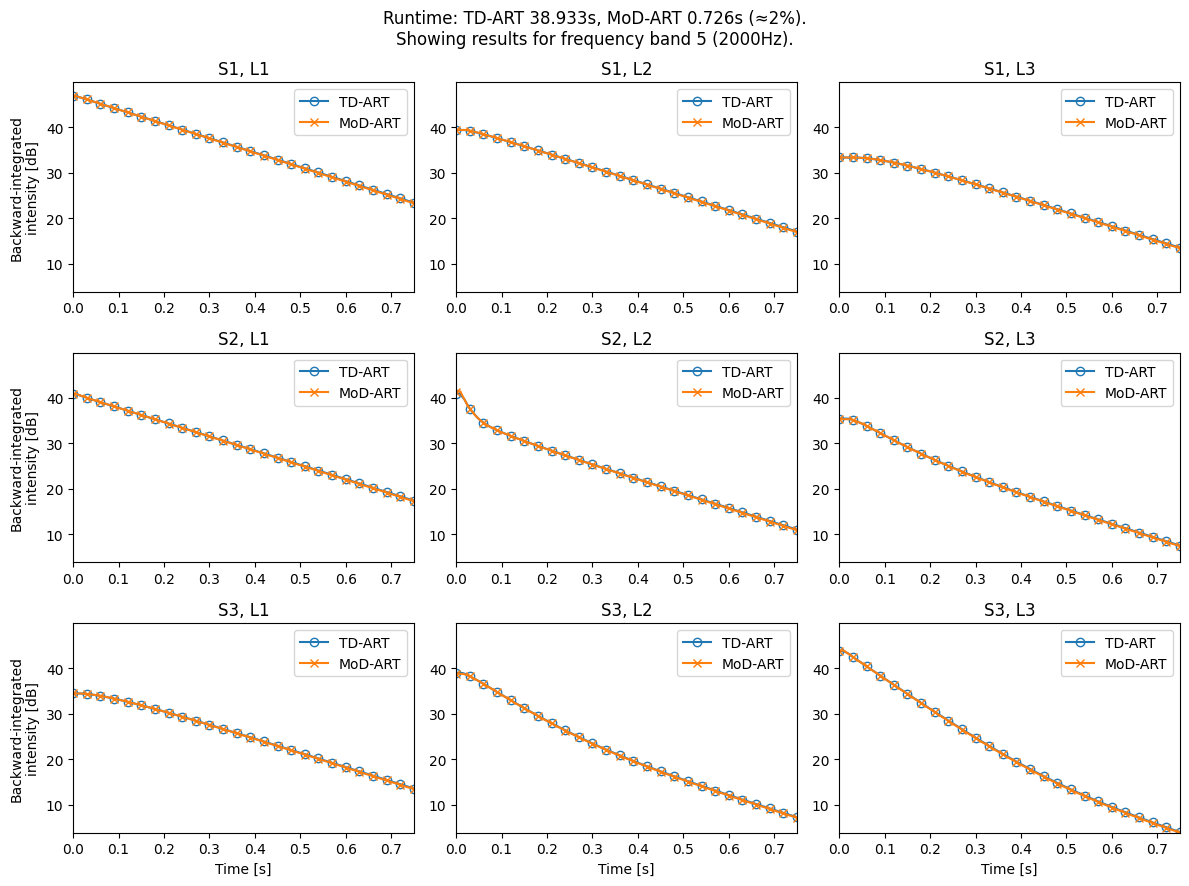

In [13]:
ART_EDCs = np.cumsum(ART_echograms[:, :, :, ::-1], axis=-1)[:, :, :, ::-1]
MoDART_EDCs = np.cumsum(MoDART_echograms[:, :, :, ::-1], axis=-1)[:, :, :, ::-1]
ART_EDCs_clipped = np.clip(ART_EDCs, 1e-20, None)
MoDART_EDCs_clipped = np.clip(MoDART_EDCs, 1e-20, None)
ART_EDCs_dB = 10 * np.log10(ART_EDCs_clipped)
MoDART_EDCs_dB = 10 * np.log10(MoDART_EDCs_clipped)

# Consider the extent of the dB range to be plotted.
max_extent = max(np.max(ART_EDCs_dB[:, :, displayed_band_idx-1, 0]),
                 np.max(MoDART_EDCs_dB[:, :, displayed_band_idx-1, 0]))
min_extent = min(np.min(ART_EDCs_dB[:, :, displayed_band_idx-1, displayed_len]),
                 np.min(MoDART_EDCs_dB[:, :, displayed_band_idx-1, displayed_len]))

fig, ax = plt.subplots(num_sources, num_listeners,
                       figsize=(4*num_listeners, 3*num_sources))

for s in range(num_sources):
    for l in range(num_listeners):
        ax[s, l].plot(echogram_time_axis, ART_EDCs_dB[s, l, displayed_band_idx-1],
                      label='TD-ART', marker='o', fillstyle='none',
                      markevery=int(3e-2 * echogram_sample_rate))
        ax[s, l].plot(echogram_time_axis, MoDART_EDCs_dB[s, l, displayed_band_idx-1],
                      label='MoD-ART', marker='x',
                      markevery=int(3e-2 * echogram_sample_rate))
        
        ax[s, l].legend()
        ax[s, l].set_xlim(0, displayed_duration)
        ax[s, l].set_ylim(min_extent, max_extent + 3)
        
        ax[s, l].set_title('S{}, L{}'.format(s+1, l+1))
        if l == 0:
            ax[s, l].set_ylabel('Backward-integrated\nintensity [dB]')
        if s == num_sources-1:
            ax[s, l].set_xlabel('Time [s]')

plt.suptitle('Runtime: TD-ART {:.3f}s, MoD-ART {:.3f}s (≈{:.0f}%).'.format(ART_runtime, MoDART_runtime, 100. * MoDART_runtime / ART_runtime)
             + '\nShowing results for frequency band {} ({:.0f}Hz).'.format(displayed_band_idx, frequencies[displayed_band_idx-1]))
plt.tight_layout()

plt.show()

## Step 5: Room impulse response generation

Echograms characterize the energy envelope of room impulse responses, but they are not sufficient for auralization.
In order to listen to the reverberation we have generated, we need to perform one last step: noise-shaping.  
Noise-shaping consists of taking a stochastic audio signal (whose energy has a constant, unit envelope) and modulating its amplitude based on the echogram.
The end result of this process is an audio-rate signal whose energy envelope matches the target echogram.  
Since we have evaluated echograms separately for different frequency bands, we will use each band's echogram to modulate an appropriately band-passed stochastic signal, and then sum the results.

In [14]:
audio_sample_rate = 48000.

### Step 5a: Up-sample the echograms

Modulating the amplitude of a signal based on another is equivalent to multiplying the signals together, element-wise.
As such, the signals need to have the same shape.  
Since we evaluated the echograms at a sample rate which is too low for auralization, we will need to up-sample them to the desired audio sample rate, such that they have the same shape as the stochastic signals.  
We need to take care to preserve each echogram's energy, and to avoid introducing negative values (which would not make physical sense).

In [15]:
# Take note of the echogram energy, to compare it after upsampling.
old_energy = np.sum(MoDART_echograms, axis=-1)

# Prepare the audio-rate time intervals at which we'll evaluate the upsampled echogram.
audio_time_axis = np.arange(0, response_duration, 1 / audio_sample_rate)
# We use a linear interpolation, because any other upsampling algorithm risks introducing negative values.
linear_spline = make_interp_spline(echogram_time_axis, MoDART_echograms, k=1, axis=-1)
upsampled_echograms = linear_spline(audio_time_axis)

# Normalize w.r.t. the new sample rate, to preserve the energy-per-second definition of echogram values.
upsampled_echograms *= echogram_sample_rate / audio_sample_rate

# Compare the new energy to the old one.
new_energy = np.sum(upsampled_echograms, axis=-1)
# The ratio (averaged over all frequency bands) should be close to 1 for all sources and listeners.
print(np.mean(old_energy / new_energy, axis=-1))

[[1.00001311 1.00000213 0.99999984]
 [1.0000236  1.00000203 0.99999995]
 [0.99999911 1.00000028 1.00001321]]


### Step 5b: Prepare the stochastic signal

Next, we need to generate a stochastic signal to modulate.
We could use a normal distribution to generate white noise, or a Poisson process to generate a sparser distribution of echoes.
In either case, we must ensure that the signal has unit energy per second, matching the convention used to generate the echograms.

In [16]:
# Random number generator.
rng = default_rng()

# White noise
#   noise_signal = rng.normal(size=len(audio_time_axis))
# Poisson process
noise_signal = rng.poisson(lam=0.5, size=len(audio_time_axis)).astype(float)

# Normalize energy per second.
noise_signal *= np.sqrt(response_duration / np.sum(noise_signal**2))

We want to modulate the stochastic signal with a different envelope within each frequency band, in order to produce frequency-dependent room impulse responses.
For that purpose, we need to split the signal we generated through a set of band-pass filters.
> **_NOTE:_** Here we assume that the frequency bands are **octave bands**, with a band boundary factor of $\sqrt{2}$. If they were, say, third-octave bands, the factor would be $\sqrt[6]{2}$.

In [17]:
# Factor for octave-band boundaries.
band_bound = np.sqrt(2)
# Consider the frequency band centers provided alongside the input data.
band_centers = frequencies

# Ensure that all frequencies support band-pass filtering.
if np.any(band_centers * band_bound >= audio_sample_rate):
    print('Warning: the audio sample rate is too low for some frequency bands.')
    # Select only acceptable bands.
    band_centers = band_centers[band_centers * band_bound < audio_sample_rate]
    # Update the number of rendered bands.
    num_bands = len(band_centers)
    # Drop unused bands from the echogram, to preserve the right shape.
    upsampled_echograms = upsampled_echograms[:, :, :num_bands]

# Prepare an array for the band-pass filtered signals.
filtered_noise_signals = np.zeros((num_bands, len(audio_time_axis)))

for b in range(num_bands):
    # Prepare the suitable band-pass filter...
    sos = butter(6, (band_centers[b] / band_bound,
                     band_centers[b] * band_bound),
                 btype='bandpass', output='sos',
                 fs=audio_sample_rate)
    # ...and apply it to the stochastic signal.
    filtered_noise_signals[b] = sosfilt(sos, noise_signal)

### Step 5c: Modulate the stochastic signal

Here's the heart of noise-shaping, pure and simple: an element-wise multiplication of the stochastic signals and the required envelopes.  
Note that the envelopes are the **square root** of the echograms &mdash; echograms are energy envelopes, we need amplitude envelopes.

After modulating the stochastic signal in each frequency band, all that's left is to add the frequencies back together.

In [18]:
# Translate the energy envelopes to amplitude envelopes.
envelopes = np.sqrt(upsampled_echograms)

# The envelope array has shape (S, L, B, T), the noise signals have shape (B, T):
#   we need to add two "leading" dimensions, which is done using [None, None].
modulated_noise_signals = envelopes * filtered_noise_signals[None, None]

# The dimension of index 2 holds the separate frequency bands.
# Sum the array along that dimension to obtain the complete room impulse responses.
responses = np.sum(modulated_noise_signals, axis=2)

### Step 5d: Auralize and visualize

To conclude the tutorial, let's listen to the room impulse responses we have generated, and plot their spectrograms.

In [19]:
for s in range(num_sources):
    for l in range(num_listeners):
        print('S{}, L{}'.format(s+1, l+1))
        display(Audio(data=responses[s, l], rate=audio_sample_rate,
                        normalize=False, embed=True))

S1, L1


S1, L2


S1, L3


S2, L1


S2, L2


S2, L3


S3, L1


S3, L2


S3, L3


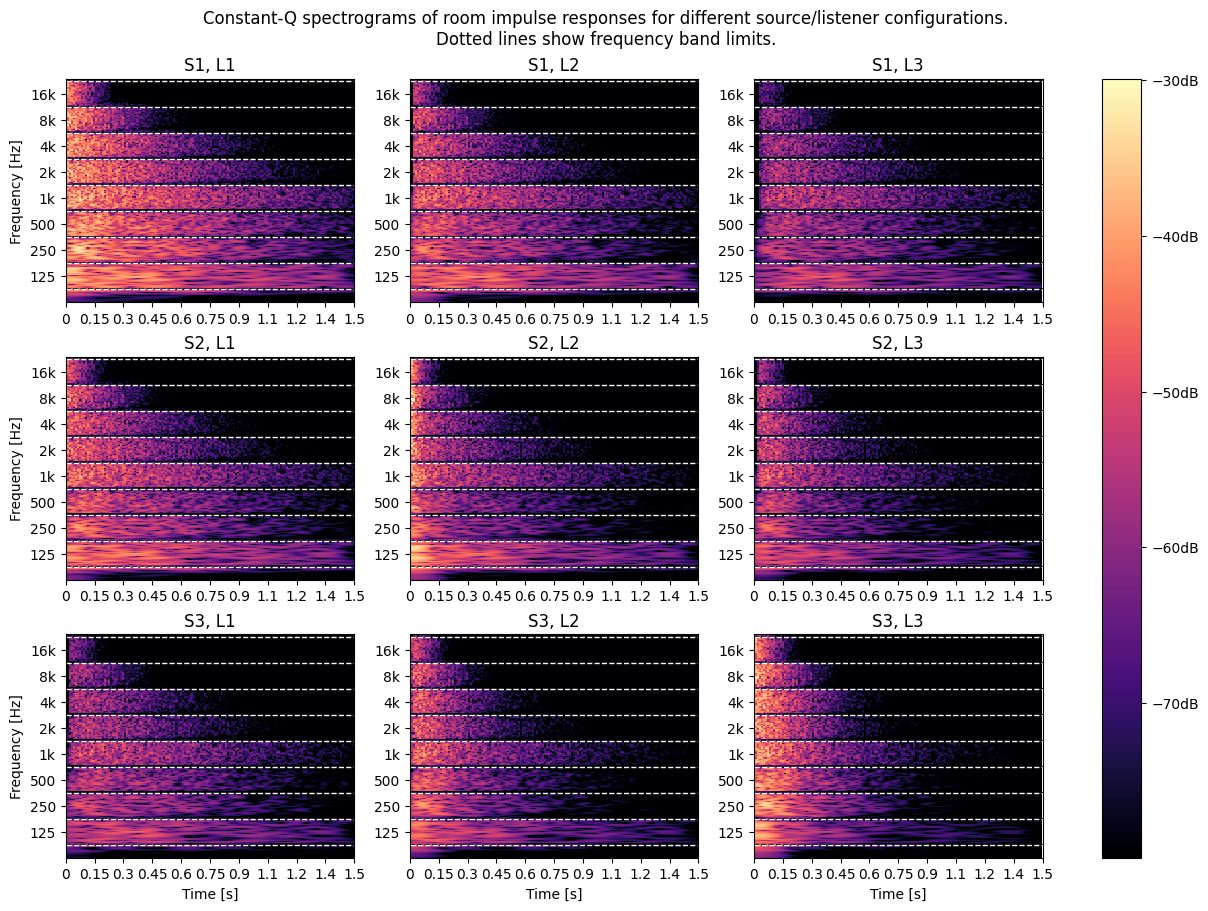

In [20]:
try:
    from librosa import amplitude_to_db
    from librosa.core import cqt
    from librosa.display import specshow
except ImportError:
    print('Install librosa to plot the spectrograms.')
else:
    bins_per_octave = 24

    fmin = band_centers[0] / 2
    fmax = audio_sample_rate / 2
    n_octaves = np.log2(fmax / fmin)
    n_bins = int(np.floor(n_octaves * bins_per_octave))
    
    band_boundaries = np.append(band_centers / band_bound,
                                band_centers[-1] * band_bound)
    
    spectrograms = cqt(y=responses, sr=audio_sample_rate,
                       bins_per_octave=bins_per_octave,
                       n_bins=n_bins, fmin=fmin)
    
    spectrograms_dB = amplitude_to_db(np.abs(spectrograms), ref=1.0)
    
    max_value = np.max(spectrograms_dB)
    min_value = max_value - 50
    
    fig, ax = plt.subplots(num_sources, num_listeners,
                           figsize=(4*num_listeners, 3*num_sources),
                           squeeze=False, constrained_layout=True)
    
    cs = None
    for s in range(num_sources):
        for l in range(num_listeners):
            cs = specshow(spectrograms_dB[s, l], sr=audio_sample_rate,
                          x_axis='time', y_axis='cqt_hz',
                          ax=ax[s, l], cmap='magma',
                          fmin=fmin, bins_per_octave=bins_per_octave,
                          vmin=min_value, vmax=max_value)
            
            line = ax[s, l].hlines(band_boundaries, 0, response_duration,
                                    color='white', ls='--', linewidth=1)
            line.set_path_effects([pathefx.Stroke(linewidth=1.5, foreground='black'),
                                   pathefx.Normal()])
    
            ax[s, l].set_xlim(0, response_duration)
            ax[s, l].set_ylim(fmin, fmax)
            
            ax[s, l].yaxis.set_major_locator(ticker.FixedLocator(band_centers))
            ax[s, l].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: (f'{int(x)}'
                                                                                    if x < 1e3 else
                                                                                    f'{int(x / 1e3)}k')))
            ax[s, l].yaxis.set_minor_locator(ticker.NullLocator())
            ax[s, l].yaxis.set_minor_formatter(ticker.NullFormatter())
            
            ax[s, l].set_title('S{}, L{}'.format(s+1, l+1))
            if l == 0:
                ax[s, l].set_ylabel('Frequency [Hz]')
            else:
                ax[s, l].set_ylabel('')
            if s == num_sources-1:
                ax[s, l].set_xlabel('Time [s]')
            else:
                ax[s, l].set_xlabel('')

    plt.suptitle('Constant-Q spectrograms of room impulse responses for different source/listener configurations.'
                 + '\nDotted lines show frequency band limits.')
    
    cbar = fig.colorbar(cs, ax=ax, format='{x:.0f}dB')

    plt.show()